In [1]:
import numpy as np
import os
import sys
import astropy as ast
from astropy.io import ascii
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import scipy as sp
from astropy.timeseries import LombScargle
from astropy import units as u
import gc
from matplotlib import rcParams
from pathlib import Path
from scipy.signal import find_peaks

In [2]:
# from view_and_clean import get_telescope, find_header_line, modified_zscore, df_extract, individual_plotter, grid_plotter, offset_corrector, offset_corrector_window
# from metrics import mean_med_flux, fit_plotter_flux, curve_fitter_flux,\
#     largest_amplitude, offset_warning, chi, percentile_amplitude, plot_percentile_amplitude, \
#         compute_lomb_scargle, plot_periodogram, plot_phase_fold, amplitude_per_period, amplitude_per_period_plot
# Skip metadata lines that begin with '#', then normalize column names.
lmc2_lc = pd.read_csv('lmc2_lc.csv', comment='#')
lmc2_lc.columns = lmc2_lc.columns.str.strip().str.replace(' ', '_', regex=False)
lmc2_lc.head()

,JD,Flux,Flux_Error,Mag,Mag_Error,Limit,FWHM,Filter,Quality,Camera
0,2.456786e+06,9.7887,0.1626,13.9830,0.0181,16.6848,1.56,V,G,bf
1,2.456789e+06,9.1232,0.1817,14.0594,0.0216,16.5642,1.58,V,G,bf
2,2.456791e+06,8.2030,0.2063,14.1749,0.0273,16.4261,1.63,V,G,bf
3,2.456792e+06,8.2990,0.1973,14.1622,0.0258,16.4743,1.71,V,G,bf
4,2.456793e+06,8.0637,0.1794,14.1934,0.0242,16.5777,1.56,V,G,bf


In [68]:
def get_telescope(image_str):
    """
    Extracts the telescope identifier from the image string.
    Parameters:
    image_str (str): The string containing the image identifier.
    Returns:
    str: The telescope identifier, or 'unknown' if not found.
    """
    # Extract the letter after 'b' in the image string
    try:
        b_index = image_str.index('b')
        if image_str[b_index + 1].isdigit():
            # If the next character is a digit, return 'unknown'
            return 'unknown'
        return image_str[b_index + 1]
    except:
        return 'unknown'
    
    
    
def find_header_line(file_path):
    """
    Finds the first non-comment, non-empty line and treats it as the header.
    Parameters:
    file_path (str): The path to the file.
    Returns:
    int: The line number of the header line, or None if not found.
    """
    with open(file_path) as f:
        for i, line in enumerate(f):
            stripped = line.strip()
            if not stripped:
                continue
            if stripped.startswith('#'):
                continue
            return i
    return None



def modified_zscore(df, values, sigma=4.0, seeoutliers=False, report=False, v2 = False):
    #Returns the modified Z-score of all points in the array. This is defined as:
    #Zm = 0.6745 * (xi - median(xi))/MAD
    #where the MAD is the median avarage deviation defined as:
    #MAD = median(abs(xi - median(xi)))
    # xi is the array of values, like fluxes.
    """    
    Calculate the modified Z-score and median absolute deviation (MAD) for a given array of values.
    Args:
        values (array-like): Input array of values, usually fluxes.
        sigma (float): Threshold for identifying outliers. Default is 4.0.
        seeoutliers (bool): If True, do not remove outliers; if False, apply modified Z-score filtering.
        report (bool): If True, print the number of outliers and their fraction in the dataset.
    Returns:
        tuple: A tuple containing:
            - Zm (array): Modified Z-scores for each value.
            - MAD (float): Median absolute deviation of the values.
            - distances (array): Distances of each value from the median.
    """
    median = np.median(values)
    distances = values - median
    MAD = np.median(abs(distances))
    Zm = 0.6745 * distances / MAD
    outlier_bool=np.zeros(len(df))
    outlier_indices= []
    # print(df.columns)
    # print(df['flux_(mJy)'])
    # outliersindices = np.where(np.abs(Zm) >= sigma)[0]
    for j in range(len(values)):
    # for j in range(len(df['flux_(mJy)'])):
        # print(f'Index {j}, Zm = {Zm[j]}')
        # try:
        if np.abs(Zm[j]) >= sigma:
            idx = df.index[j]
            # print(idx)
            # print(f'Outlier detected at index {j} with Zm = {Zm[j]}')
            outlier_indices.append(idx)
            if seeoutliers==False:
                mag_col = 'Mag' if 'Mag' in df.columns else 'mag'
                mag_err_col = 'Mag_Error' if 'Mag_Error' in df.columns else 'mag_err'
                flux_col = 'Flux' if 'Flux' in df.columns else ('flux' if 'flux' in df.columns else 'flux_(mJy)')
                flux_err_col = 'Flux_Error' if 'Flux_Error' in df.columns else 'flux_err'
                df.loc[idx, mag_col] = np.nan
                df.loc[idx, mag_err_col] = np.nan
                df.loc[idx, flux_col] = np.nan
                df.loc[idx, flux_err_col] = np.nan
                outlier_bool[j]=1.
        # except Exception as e:
        #     print(f"Error processing index {j}: {e}")
            # outlier_indices.append(j)
    if report==True and len(outlier_indices) > 0: 
        print(f'Number of outliers: {len(outlier_indices)}, Outlier fraction: {len(outlier_indices)/len(df)}')
    return df,Zm,MAD,distances,outlier_indices




def df_extract(g = True, seeoutliers=False, report=False):
    """
    Extracts data from a file based on the given index and whether to use 'g' or 'V' band data.
    Args:
        index (int): The index of the coordinates to use for file naming.
        g (bool): If True, use 'g' band data; if False, use 'V' band data.
        seeoutliers (bool): If True, do not remove outliers; if False, apply modified Z-score filtering.
        report (bool): If True, print the number of outliers and their fraction in the dataset.
    Returns:
        df (DataFrame): A pandas DataFrame containing the extracted data.
        telescopes (array): Unique telescopes found in the data.
    """

    file_path = os.path.join('lmc2_lc.csv')
    # Read the data
    header_line = find_header_line(file_path)
    if header_line is None:
        raise ValueError("Could not find header line starting with ###")

    # Read the header line and infer delimiter style.
    with open(file_path) as f:
        for j, line in enumerate(f):
            if j == header_line:
                header_text = line.strip().lstrip('#').strip()
                break

    delimiter = ',' if ',' in header_text else r'\s+'

    if delimiter == ',':
        # ASAS-SN CSV style with metadata comments.
        df = pd.read_csv(file_path, comment='#')
    else:
        # Older whitespace-delimited exports.
        column_names = header_text.replace('Flux Error', 'Flux_Error').replace('Mag Error', 'Mag_Error').split()
        df = pd.read_csv(
            file_path,
            skiprows=header_line + 1,
            comment='#',
            sep=r'\s+',
            names=column_names,
        )

    # Normalize columns for downstream code (e.g. 'Flux Error' -> 'Flux_Error').
    df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False)
    
    # Modified Z-score filtering; If seeoutliers is True, we will not remove outliers
    if seeoutliers==False:
        df = modified_zscore(df, df['Flux'], report=report)[0]

    # Drop rows with NaN values in any column
    df = df.dropna(axis=0, how='any')

    # Drop rows where Flux is less than Flux_Error
    df = df[df['Flux'] >= 3*df['Flux_Error']]
    # drop is error bigger than 1 mag
    df = df[df['Mag_Error'] < 1]

    # Drop rows where Flux_Error is zero
    df = df[df['Flux_Error'] > 0]

    # Where mag_err is < 0.01, we set it to 0.01, and accordingly set flux_err
    df.loc[df['Mag_Error'] < 0.01, 'Mag_Error'] = 0.01
    # for only the changed mag_err values, we need to recalculate flux_err
    df.loc[df['Mag_Error'] < 0.01, 'Flux_Error'] = df['Mag_Error'] * df['Flux'] * np.log(10) / 2.5

    # Second filter: Drop rows where 'mag' originally had a '>' character
    df = df[~df['Mag'].astype(str).str.startswith('>')]

    # Sometimes the 'mag' column is strings, so we need to convert it to numeric
    df = df[pd.to_numeric(df["Mag"], errors="coerce").notna()]
    df["Mag"] = pd.to_numeric(df["Mag"], errors="coerce")
    # only use where filter is g
    # df = df[df['Filter'] == ('g')]

    # Reset the index of the DataFrame (most functions work without this, but it is good practice)
    df = df.reset_index(drop=True)

    df['telescope'] = df['Camera'].apply(get_telescope)
    telescopes = df['telescope'].unique()
    return df, telescopes




def individual_plotter( tail=1, g=True, seeoutliers=False, report=True):  
    """
    Plots the light curve for a given index, either in g-band or V-band.
    Args:
        index (int): Index of the object in the coordinates DataFrame.
        g (bool): If True, plot g-band light curve; if False, plot V-band light curve.
        seeoutliers (bool): If True, do not filter outliers; if False, apply modified Z-score filtering.
    """

    colors = ['g', 'b', 'r', 'c', 'm', 'y', 'k']  # Different colors for different telescopes

    # df, telescopes = df_extract(index, g=g, seeoutliers=seeoutliers, report=report)
    df, telescopes = df_extract( g=g, seeoutliers=False, report=report)
    # RA = coords[index]['RA']
    # dec = coords[index]['DEC']

    # if seeoutliers==True:
    #     print('right before modified z-score')
    #     # df,Zm,MAD,distances,outlierindices = modified_zscore(df, df['flux_(mJy)'], seeoutliers=seeoutliers, report=report)  # Apply modified Z-score filter
    #     outlierindices = modified_zscore(df, df['flux_(mJy)'], seeoutliers=seeoutliers, report=report)[4]  # Get outlier indices
    #     print('right after modified z-score')
    if report:
        # Print summary of data points per telescope
        print("\nNumber of observations per telescope:")
        if g:
            print("g-band:")
        else:
            print("\nV-band:")
        print(df.groupby('telescope').size())

    # Plot data
    plt.figure(figsize=(12, 6))
    if g:
        for i, tel in enumerate(telescopes):
            mask = df['telescope'] == tel
                # plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                #     fmt='o', markeredgecolor = 'black', capsize = 5, color=colors[i % len(colors)], zorder = 10, # 
                #     label=f'g-band (telescope {tel})')
            if tel in ['k', 'l', 'p', 'H']:
                plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                            fmt='o', markeredgecolor = 'black', capsize = 5, color='green', zorder = 10), # colors[i % len(colors)])
                if tel in ['k']:
                    plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                                fmt='o', markeredgecolor = 'black', label=f'g-band', capsize = 5, color='green', zorder = 10), # colors[i % len(colors)])
        
            elif tel in ['f', 'h']:
                plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                            fmt='o', markeredgecolor = 'black', capsize = 5, color='skyblue', zorder = 10), # colors[i % len(colors)])
                if tel in ['f']:
                    plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                                fmt='o', markeredgecolor = 'black', label=f'V-band', capsize = 5, color='skyblue', zorder = 10), # colors[i % len(colors)])
        
            
        # if seeoutliers==True:
        #     # if len(outlierindices) > 0:
        #     #     for badindex in outlierindices:
        #     #             plt.plot(df.loc[badindex]['JD'], df.loc[badindex]['mag'], 'x', color=colors[i % len(colors)], markersize=25, markeredgecolor='black', zorder=10)
        #     fulldata = df_extract(index, g=g, seeoutliers=True, report=report)[0]
        #     plt.errorbar(fulldata['JD'], fulldata['Mag'], yerr=fulldata['Mag_Error'],
        #                 fmt='.', color='black', markersize=10,capsize = 5, markeredgecolor='black',
        #                 label='Outliers')


    else:
        # for i, tel in enumerate(telescopes):
        #     mask = df['telescope'] == tel
        plt.errorbar(df[mask]['JD'], df[mask]['Mag'],  yerr=df[mask]['Mag_Error'],
                    fmt='o', markeredgecolor = 'black', capsize = 5, color=colors[i % len(colors)],
                    label=f'V-band (telescope {tel})')

        if seeoutliers:
            # if len(outlierindices) > 0:
            #     for badindex in outlierindices:
            #             plt.plot(df.loc[badindex]['JD'], df.loc[badindex]['mag'], 'x', color=colors[i % len(colors)], markersize=25, markeredgecolor='black', zorder=10)
            plt.errorbar(fulldata['JD'], fulldata['Mag'], yerr=fulldata['Mag_Error'],
                        fmt='.', color='black', markersize=10,capsize = 5, markeredgecolor='black')

    plt.vlines(x=2458500, ymin=12.5, ymax=17.0, color='gray', linestyle='--', label='2020')
    plt.ylim(12.75,16.75)
    plt.xlabel('JD', fontsize=18)
    plt.ylabel('Magnitude', fontsize=18)
    # plt.title(f'LMC2', fontsize=20)
    plt.legend(loc='lower right', fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.gca().invert_yaxis()  # Invert y-axis since smaller magnitudes are brighter
    plt.tick_params(axis='both', direction='in', labelsize=16)
    # plt.savefig(f'figs/offsets_examples/{RA}{dec}_g.png')
    # plt.savefig(f'figs/lc_plots/{RA}{dec}_g.png', bbox_inches='tight', dpi=300)
    plt.show()







Number of outliers: 155, Outlier fraction: 0.049679487179487176

Number of observations per telescope:
g-band:
telescope
H    711
f    124
h    294
k    556
l    551
p    726
dtype: int64


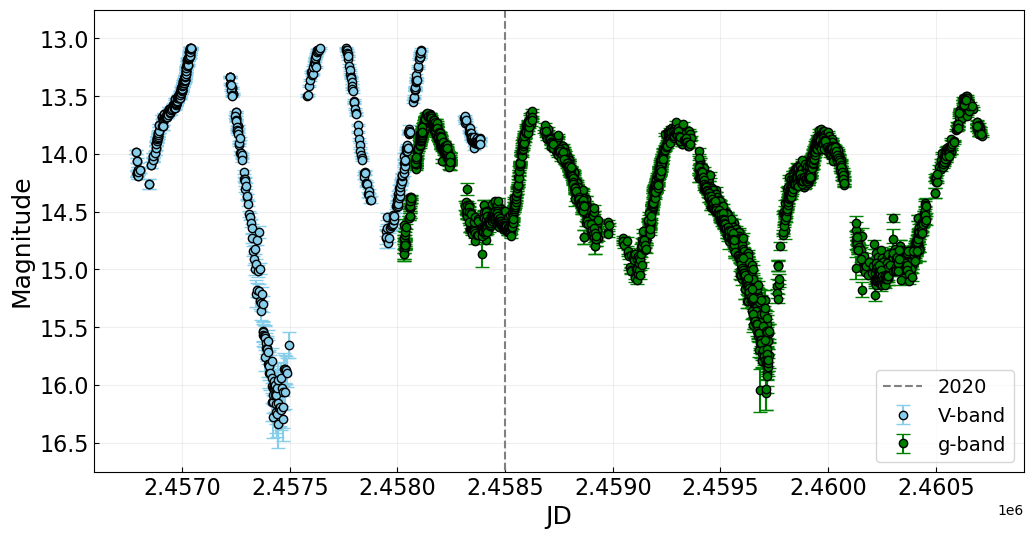

In [69]:
individual_plotter( g=True, seeoutliers=False, report=True)

In [5]:
def compute_lomb_scargle(df=None, telescopes=None, g=True, auto=False, median=True, samples_per_peak=5, report=True, show=False, subtract_median=True):
    """
    Compute the Lomb-Scargle periodogram for a given object index.  
    Parameters:
    -----------
    index : int
        Index of the object in the dataset
    auto : bool
        If True, use autopower to automatically determine frequency range and resolution
    samples_per_peak : int
        Number of samples per peak in the periodogram
    median : bool
        If True, use the median flux for aliasing; otherwise, do not remove aliases
    report : bool
        If True, print the best frequency, period, and maximum power
    subtract_median : bool
        If True, subtract the median flux from the values before computing the periodogram
    Returns:
    --------
    dict : Dictionary containing frequency, power, best frequency, best period, maximum power, false alarm probability, and peaks
    """

    df, telescopes = df_extract()
    time = np.array(df['JD'])
    values = np.array(df['Flux']) 
    errors = np.array(df['Flux_Error'])  
    if subtract_median:
        values -= np.median(values)
    
    ls = LombScargle(time, values, dy=errors)
    peaks = []
    peak_powers = []
    min_freq = 2.0 / (time.max() - time.min())  # Longest period is half the observation period
    max_freq = 0.9 

    # alias
    # lsalias = LombScargle(time, np.full_like(df['Flux'], df['Flux'].median()), dy=errors)

    # Calculate periodogram
    if auto is not True:
        frequency = np.linspace(min_freq, max_freq, 
                              int((max_freq - min_freq) * len(time) * samples_per_peak))
        power = ls.power(frequency)
    else:
        frequency, power = ls.autopower(samples_per_peak=samples_per_peak)

    probabilities = 0.01
    alarm_level = ls.false_alarm_level(probabilities)
    noise_level = alarm_level.item()  # Convert to Python scalar
    # alias_alarm_level = lsalias.false_alarm_level(probabilities).item()
    # if report:
    #     print(f"FAL: {alarm_level:.8f}, Alias FAL: {alias_alarm_level:.8f}")



    # alias = aliasing(index, auto=auto, median = median, samples_per_peak=samples_per_peak, show=False)
    findpeaks = find_peaks(power, height= noise_level, distance=samples_per_peak) 
    peaks = frequency[findpeaks[0]]
    peak_powers = findpeaks[1]['peak_heights']

    # Convert alias peak indices to frequencies
    # alias_frequencies = alias[0][alias[2][0]] if len(alias[2][0]) > 0 else [] 

    # this part is to normalize the alias powers to match the top peak of the original periodogram (top peak without removing aliases)
    if len(peak_powers) > 0:
        max_power = np.max(peak_powers) # max power of the original periodogram BEFORE alias removal
    else:
        max_power = np.max(power)
    # alias_power_normalized = alias[1] * (max_power / np.max(alias[1]))
    # alias = (alias[0], alias_power_normalized, alias[2])
    # alias_FAP = lsalias.false_alarm_probability(max_power)  # Calculate FAP for alias
    # if report:
    #     print(f"Alias false alarm probability: {alias_FAP:.3e}")

    # print(f"Peaks before aliasing check: {len(peaks)}")
    peaks_list = list(peaks)
    peak_powers_list = list(peak_powers)
    # print(len(peaks_list), len(peak_powers_list))
    
    # if len(peaks_list) > 0 and len(alias_frequencies) > 0: # if there are peaks and alias frequencies
    #     # Keep track of peaks to remove to avoid duplicates
    #     peaks_to_remove = []
    #     for alias_peak in alias_frequencies:
    #         for i, peak in enumerate(peaks_list):
    #             if abs(alias_peak - peak)/(alias_peak**2) < 0.5 and i not in peaks_to_remove:
    #                 if report:
    #                     print(f"Warning: Peak at {peak:.8f} 1/day is aliased (close to {alias_peak:.8f} 1/day).")
    #                 peaks_to_remove.append(i)
    #                 break  # only remove each peak once
        
        # # remove peaks in reverse order to maintain correct indices
        # for i in sorted(peaks_to_remove, reverse=True):
        #     # if i == 
        #     peaks_list.pop(i)
        #     peak_powers_list.pop(i)

        # peaks = np.array(peaks_list)
        # peak_powers = np.array(peak_powers_list)
        # # print(f"Peaks after aliasing check: {len(peaks)}")

    # if there are no peaks above false alarm level (nonvariable):
    if len(peaks) == 0:
        findpeaks = find_peaks(power, height=0, distance=samples_per_peak)
        peaks = frequency[findpeaks[0]]
        peak_powers = findpeaks[1]['peak_heights']
        best_freq = peaks[np.argmax(peak_powers)] # find peak with highest power, even below FA level
        best_period = 1.0 / best_freq
        max_power = np.max(peak_powers)
        alarm = ls.false_alarm_probability(max_power) 
    # if there are peaks above false alarm level (variable):
    else:
        best_freq = peaks[np.argmax(peak_powers)]
        best_period = 1.0 / best_freq
        max_power = np.max(peak_powers)
        alarm = ls.false_alarm_probability(max_power)

    alarm_level_flag = 0
    # if highest peak is under false alarm level, set flag for non-variability
    if max_power < alarm_level:
        alarm_level_flag = 1
    
    if report:
        print(f"Best frequency: {best_freq:.6f} 1/day, Best period: {best_period:.2f} days, Max power: {max_power:.3f}, False alarm probability: {alarm:.3e}")
        print(f"False alarm level for {probabilities*100:.1f}%: {alarm_level:.3e}")

    # # normalize alias powers to match top peak of original periodogram
    # alias_power_normalized = alias[1] * (max_power / np.max(alias[1]))
    # alias = (alias[0], alias_power_normalized, alias[2])

    if show:
        fig = plt.figure(figsize=(10, 6))
        # plt.plot(alias[0], alias[1], color='tab:blue', linestyle='-', linewidth=1)
        plt.plot(frequency, power, color='tab:blue', linestyle='-', linewidth=1, label = 'Original Periodogram')
        # plt.plot(alias[0], alias[1], color='tab:orange', linestyle='-', alpha = 0.8, linewidth=1, label = 'Aliases')
        plt.xlim(0, max_freq)
        if best_freq > 0:
            plt.axvline(x=best_freq, color='red', linestyle='--', alpha=0.7,
                        label=f'Best Period after alias removal = {1/best_freq:.2f} days')
        plt.axhline(y=alarm_level, color='grey', linestyle='--', label = 'FA level of original periodogram')
        # plt.axhline(y=alias_alarm_level, color='orange', linestyle='--', label = 'FA level of aliases')
        plt.xlim(0,0.06)
        plt.xlabel('Frequency (1/day)')
        plt.ylabel('Power')
        plt.legend()
        # plt.ylim(0, np.max(power) * 1.1)
        plt.show()
        plt.close(fig)

    return {
        'frequency': frequency,
        'power': power,
        'best_frequency': best_freq,
        'best_period': best_period,
        'max_power': max_power,
        'false_alarm_prob': alarm,
        'false_alarm_level': alarm_level,
        'peaks': peaks,
        'peak_powers': peak_powers,
        'observation_period': time.max() - time.min(),
        'alarm_level_flag': alarm_level_flag,
        'findpeaks': findpeaks
    }


def plot_periodogram(frequency, power, best_freq, false_alarm_level, title="Lomb-Scargle Periodogram", auto=False, show_best=True):
    """
    Plot the Lomb-Scargle periodogram.
    
    Parameters:
    -----------
    frequency : array-like
        Frequency values
    power : array-like
        Power values
    title : str
        Plot title
    freq_range : tuple or None
        (min_freq, max_freq) for x-axis limits
    show_best : bool
        Whether to mark the highest power peak
    """

    print(f"Grid sampled at {len(frequency)} points")
    fig = plt.figure(figsize=(10, 6))
    plt.plot(frequency, power, color='tab:blue', linestyle='-', linewidth=1)
    # plt.ylim(0, np.max(power) * 1.1)  # Set y-axis limit to 10% above max power
    
    if show_best:
        best_idx = np.where(frequency == best_freq)[0][0]  # Find index in frequency array
        plt.axvline(x=frequency[best_idx], color='red', linestyle='--', alpha=0.7, 
                   label=f'Best Period = {1/frequency[best_idx]:.2f} days')
        plt.plot(frequency[best_idx], power[best_idx], 'ro', markersize=8)
        # for peak in peaks:
        #     if peak != frequency[best_idx]:  # Exclude the tallest peak
        #         plt.axvline(x=peak, color='green', linestyle='--', alpha=0.5,
        #                    label=f'Peak at {1/peak:.2f} days')
    
    if auto is not True:
        plt.xlim(0, 0.9)
        plt.xlim(0,0.05)
        # plt.xlim(0, 0.4)
    
    if show_best:
        plt.legend(fontsize=14)
    plt.axhline(y=false_alarm_level, color='grey', linestyle='--',
                label=f'False Alarm Level ({100*0.01:.1f}%): {false_alarm_level:.3e}')
    plt.xlabel('Frequency (1/day)', fontsize=16)
    plt.ylabel('Power', fontsize=16)
    plt.tick_params(axis='both', which='major', direction ='in', labelsize=16)
    plt.grid(True, alpha=0.3)
    # plt.title(f'{RA} {dec} periodogram', fontsize=14)
    # plt.tight_layout()
    # plt.savefig(f'figs/lc_plots/{RA}{dec}_periodogramg.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_phase_fold(best_period, df=None, telescopes=None, g=True, phase_bins=2, correct_offsets=True, mag_space=False):
    """
    Phase fold time series data using a given period.
    
    Parameters:
    -----------
    time : array-like
        Time values
    period : float
        Period to fold by
    values : array-like or None
        Data values to fold
    errors : array-like or None
        Uncertainties in data values
    phase_bins : float
        Number of phase cycles to show (e.g., 2 shows 0-2 phases)
        
    Returns:
    --------
    dict : Dictionary containing phased data
    """

    df, telescopes = df_extract()

    time = np.array(df['JD'])  # Time in HJD
    flux = np.array(df['Flux'])  # Flux in mJy
    mags = np.array(df['Mag'])  # Magnitudes
    flux_errors = np.array(df['Flux_Error'])  # Flux uncertainties in mJy
    mag_errors = np.array(df['Mag_Error'])  # Magnitude uncertainties
    # period = lombs['best_period']  # Best period from Lomb-Scargle analysis
    # period = 30.89
    if best_period > (time.max() - time.min()):
        return None
    # Calculate phase
    colors = ['g', 'b', 'r', 'c', 'm', 'y', 'k']
    phased_time = (time / best_period) % phase_bins

    plt.figure(figsize=(10, 6))
    # colour by telescope:
    for i, telescope in enumerate(telescopes):
        mask = df['telescope'] == telescope
        if mag_space:
            plt.errorbar(phased_time[mask], mags[mask], yerr=mag_errors[mask], capsize=5, markeredgecolor='black', fmt='o', label=f'Telescope {telescope}', color=colors[i % len(colors)])
            # bin and plot median in each phase bin for magnitudes:
        else:
            plt.errorbar(phased_time[mask], flux[mask], yerr=flux_errors[mask], capsize=5, markeredgecolor='black', fmt='o', label=f'Telescope {telescope}', color=colors[i % len(colors)])
    # if mag_space:
    #     num_bins = int(np.ceil(len(phased_time) / 10))
    #     bins = np.linspace(0, phase_bins, num_bins + 1)
    #     bin_indices = np.digitize(phased_time, bins) - 1
    #     bin_centers = (bins[:-1] + bins[1:]) / 2
    #     mean_mags = [np.mean(mags[bin_indices == j]) for j in range(num_bins)]
    #     plt.plot(bin_centers, mean_mags, color='black', linestyle='-', marker='s', markersize=6, label=f'Mean {telescope}', zorder = 12)
    plt.legend(fontsize=12)
    # single colour:
    # plt.errorbar(phased_time, flux, yerr=errors, fmt='o', alpha=0.7, markersize=4)
    plt.xlabel('Phase', fontsize=14)
    if mag_space:
        plt.ylabel('Magnitude', fontsize=14)
        plt.gca().invert_yaxis()  # Invert y-axis for magnitudes
    else:
        plt.ylabel('Flux (mJy)', fontsize=14)
    plt.tick_params(axis='both', which='major', direction ='in', labelsize=14)
    plt.grid(True, alpha=0.3)
    plt.title(f'LMC-2;(2 phases with period = {best_period:.2f} days)', fontsize=14)
    plt.tight_layout()
    # plt.savefig(f'figs/lc_plots/{RA}{dec}_phaseg.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Bin and find amplitude of narrow bin
    num_bins = int(np.ceil(len(phased_time) / 10))  # e.g., ~10 points per bin
    bins = np.linspace(0, phase_bins, num_bins + 1)
    bin_indices = np.digitize(phased_time, bins) - 1

    amplitudes = []
    for i in range(num_bins):
        bin_flux = flux[bin_indices == i]
        if len(bin_flux) > 1:
            amplitude = np.max(bin_flux) - np.min(bin_flux)
            amplitudes.append(amplitude)
    average_amplitude = np.mean(amplitudes)
    print(f"Average scatter (amplitude) per 10 point phase bin: {average_amplitude:.3f} mJy")
    return average_amplitude


def plot_phase_fold_binned(best_period, df=None, telescopes=None, g=True, phase_bins=2, correct_offsets=True, mag_space=False):
    """
    Phase fold time series data using a given period.
    
    Parameters:
    -----------
    time : array-like
        Time values
    period : float
        Period to fold by
    values : array-like or None
        Data values to fold
    errors : array-like or None
        Uncertainties in data values
    phase_bins : float
        Number of phase cycles to show (e.g., 2 shows 0-2 phases)
        
    Returns:
    --------
    dict : Dictionary containing phased data
    """

    df, telescopes = df_extract()

    time = np.array(df['JD'])  # Time in HJD
    flux = np.array(df['Flux'])  # Flux in mJy
    mags = np.array(df['Mag'])  # Magnitudes
    flux_errors = np.array(df['Flux_Error'])  # Flux uncertainties in mJy
    mag_errors = np.array(df['Mag_Error'])  # Magnitude uncertainties
    # period = lombs['best_period']  # Best period from Lomb-Scargle analysis
    # period = 30.89
    if best_period > (time.max() - time.min()):
        return None
    # Calculate phase
    colors = ['g', 'b', 'r', 'c', 'm', 'y', 'k']
    phased_time = (time / best_period) % phase_bins

    plt.figure(figsize=(10, 6))
    # colour by telescope:
    for i, telescope in enumerate(telescopes):
        mask = df['telescope'] == telescope
        if mag_space:
            plt.errorbar(phased_time[mask], mags[mask], yerr=mag_errors[mask], capsize=5, markeredgecolor='black', fmt='o', label=f'Telescope {telescope}', color=colors[i % len(colors)], alpha = 0.2)
            # bin and plot median in each phase bin for magnitudes:
        else:
            plt.errorbar(phased_time[mask], flux[mask], yerr=flux_errors[mask], capsize=5, markeredgecolor='black', fmt='o', label=f'Telescope {telescope}', color=colors[i % len(colors)], alpha = 0.2)
    if mag_space:
        num_bins = int(np.ceil(len(phased_time) / 50))
        bins = np.linspace(0, phase_bins, num_bins + 1)
        bin_indices = np.digitize(phased_time, bins) - 1
        bin_centers = (bins[:-1] + bins[1:]) / 2
        mean_mags = [np.mean(mags[bin_indices == j]) for j in range(num_bins)]
        plt.plot(bin_centers, mean_mags, color='black', linestyle='-', marker='s', markersize=6, label=f'Mean', zorder = 12)
    plt.legend(fontsize=12)
    # single colour:
    # plt.errorbar(phased_time, flux, yerr=errors, fmt='o', alpha=0.7, markersize=4)
    plt.xlabel('Phase', fontsize=14)
    if mag_space:
        plt.ylabel('Magnitude', fontsize=14)
        plt.gca().invert_yaxis()  # Invert y-axis for magnitudes
    else:
        plt.ylabel('Flux (mJy)', fontsize=14)
    plt.tick_params(axis='both', which='major', direction ='in', labelsize=14)
    plt.grid(True, alpha=0.3)
    plt.title(f'LMC-2; (2 phases with period = {best_period:.2f} days)', fontsize=14)
    plt.tight_layout()

    plt.show()

    # Bin and find amplitude of narrow bin
    num_bins = int(np.ceil(len(phased_time) / 10))  # e.g., ~10 points per bin
    bins = np.linspace(0, phase_bins, num_bins + 1)
    bin_indices = np.digitize(phased_time, bins) - 1

    amplitudes = []
    for i in range(num_bins):
        bin_flux = flux[bin_indices == i]
        if len(bin_flux) > 1:
            amplitude = np.max(bin_flux) - np.min(bin_flux)
            amplitudes.append(amplitude)
    average_amplitude = np.mean(amplitudes)
    print(f"Average scatter (amplitude) per 10 point phase bin: {average_amplitude:.3f} mJy")
    return average_amplitude


Best frequency: 0.001610 1/day, Best period: 620.98 days, Max power: 0.701, False alarm probability: 0.000e+00
False alarm level for 1.0%: 1.146e-02
[0.0011386  0.00161036 0.00216075 0.00255388 0.00326153 0.00365466
 0.00444093 0.00499131 0.00632797 0.01151734 0.03227481 0.03557713]
Grid sampled at 11438 points


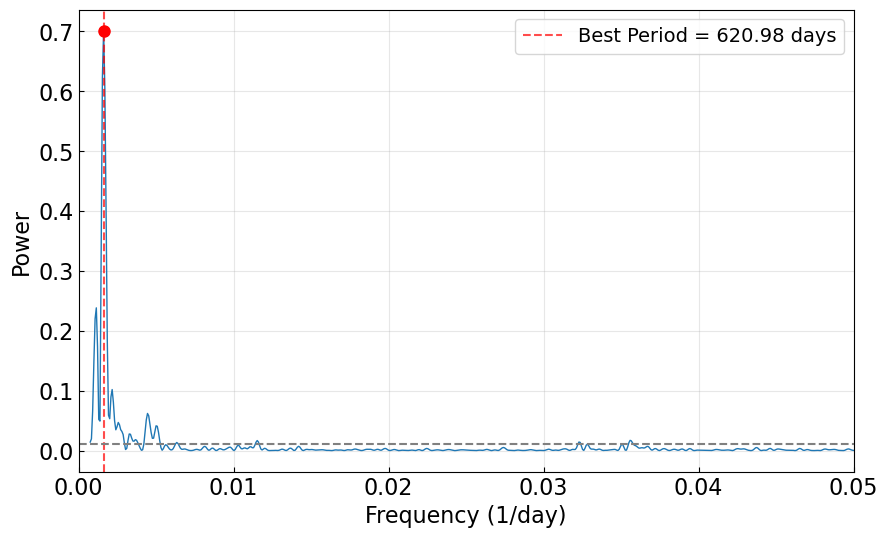

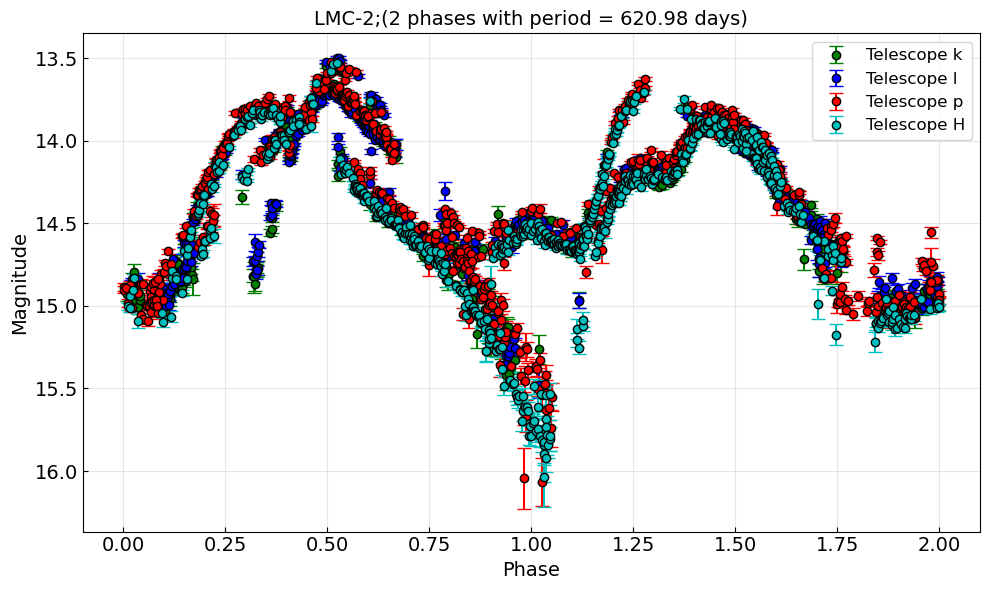

Average scatter (amplitude) per 10 point phase bin: 2.028 mJy


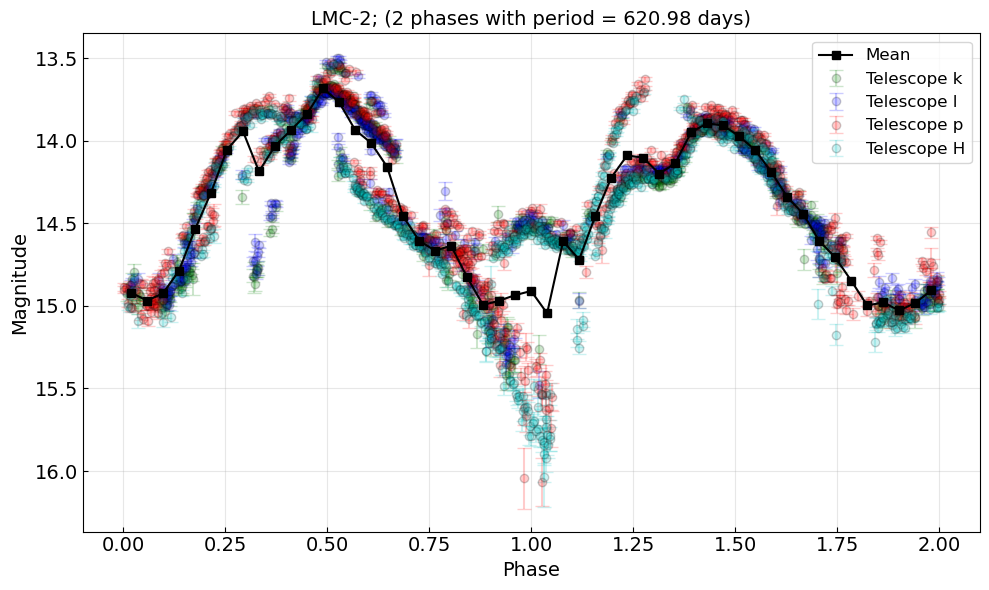

Average scatter (amplitude) per 10 point phase bin: 2.028 mJy


np.float64(2.0276927710843373)

In [6]:
lombs = compute_lomb_scargle()
best_period = lombs['best_period']
print(lombs['peaks'])
plot_periodogram(lombs['frequency'], lombs['power'], lombs['best_frequency'], lombs['false_alarm_level'], lombs['peaks'], lombs['observation_period'], show_best=True)
plot_phase_fold(best_period, phase_bins=2, mag_space=True)
plot_phase_fold_binned(best_period, phase_bins=2, mag_space=True)


In [7]:
# −5.65±0.96 in abs V band

In [8]:
# −10.50±0.03 in abs K_s band

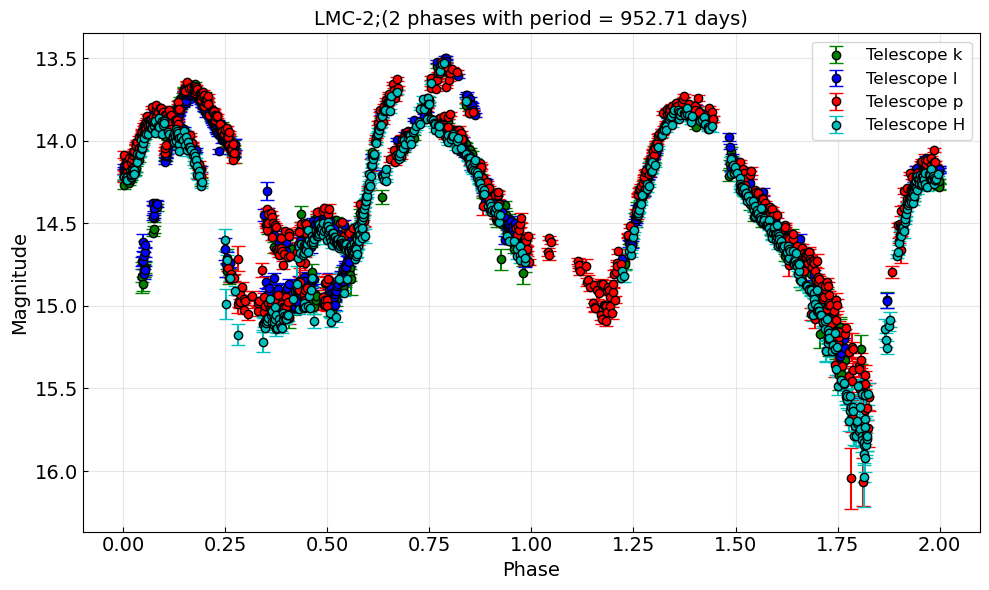

Average scatter (amplitude) per 10 point phase bin: 1.561 mJy


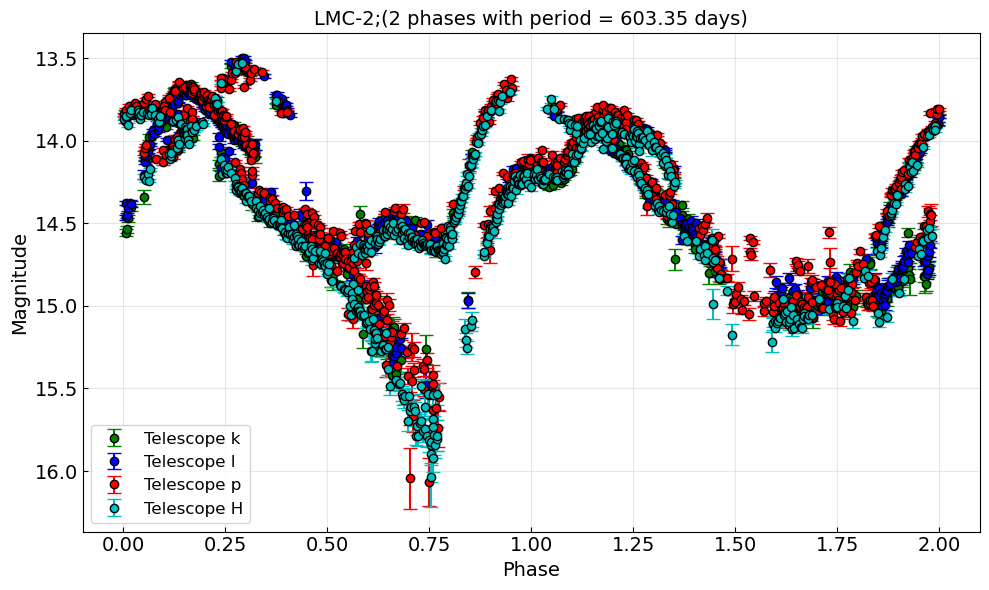

Average scatter (amplitude) per 10 point phase bin: 2.488 mJy


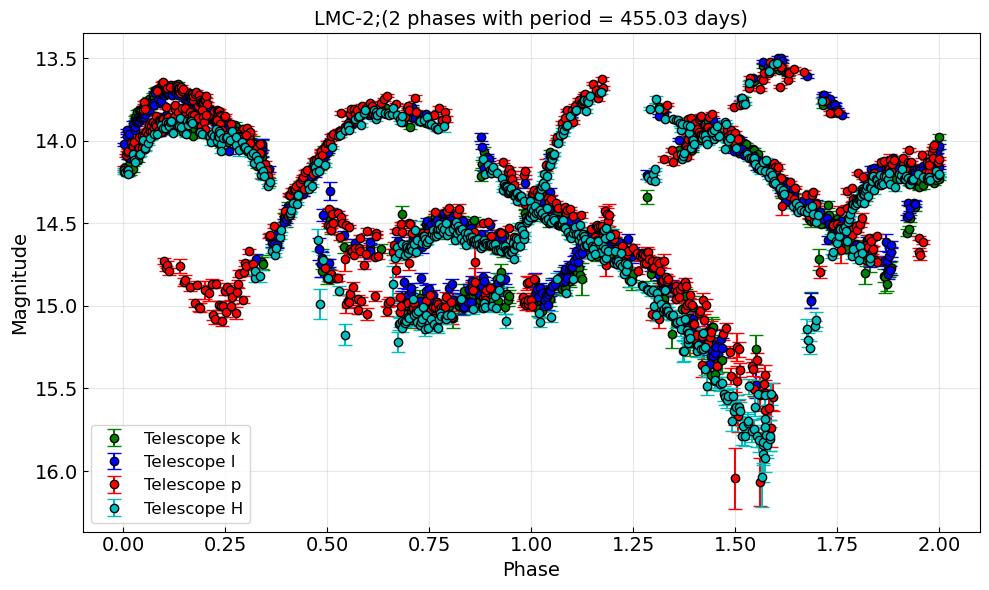

Average scatter (amplitude) per 10 point phase bin: 4.816 mJy


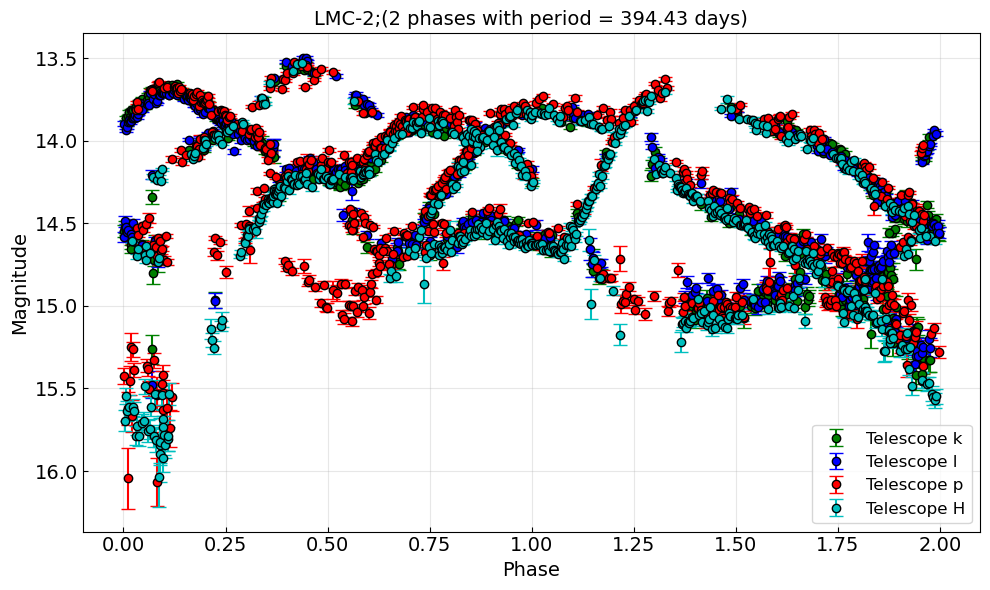

Average scatter (amplitude) per 10 point phase bin: 5.392 mJy


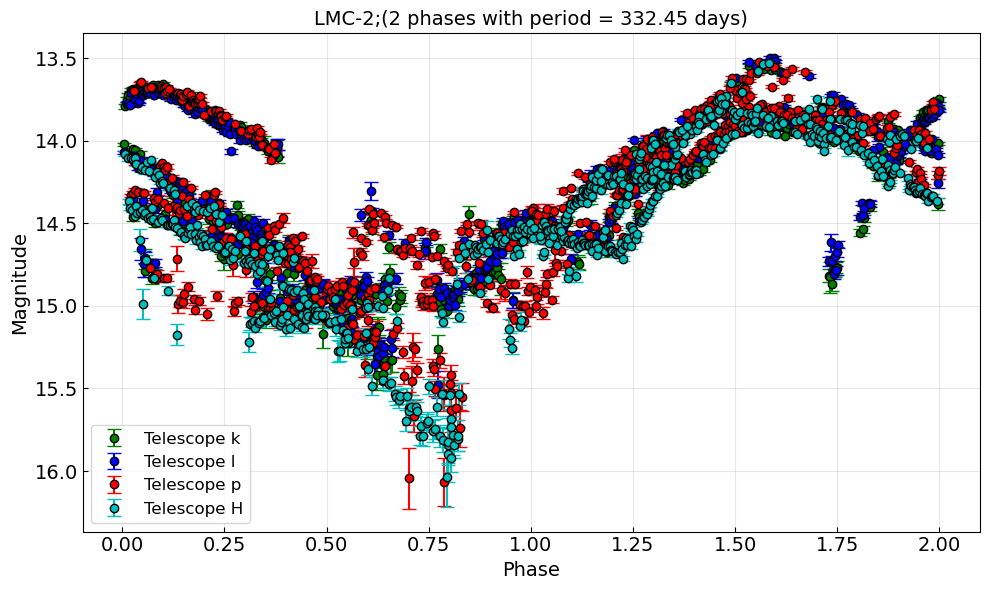

Average scatter (amplitude) per 10 point phase bin: 3.333 mJy


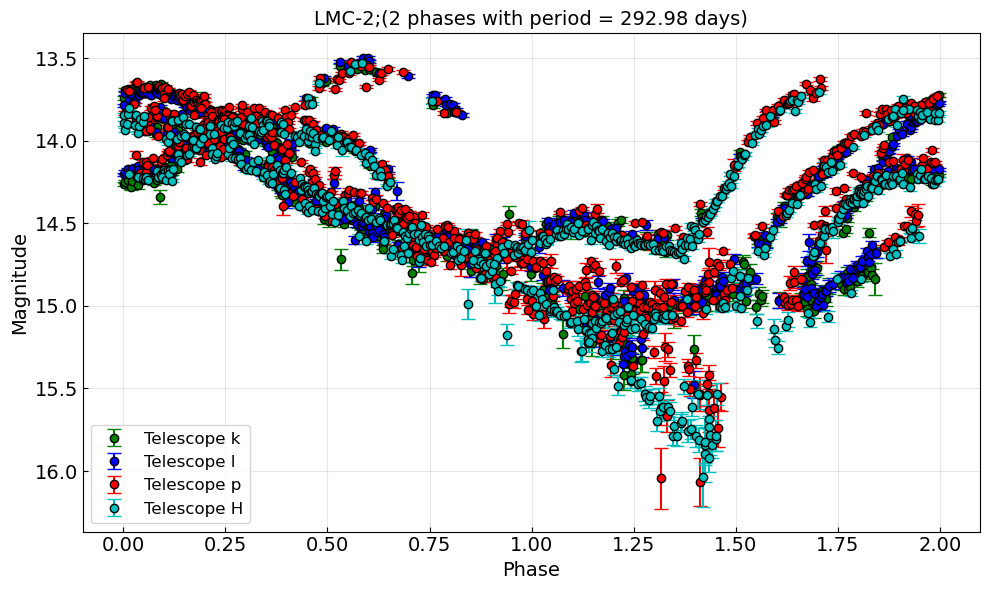

Average scatter (amplitude) per 10 point phase bin: 4.035 mJy


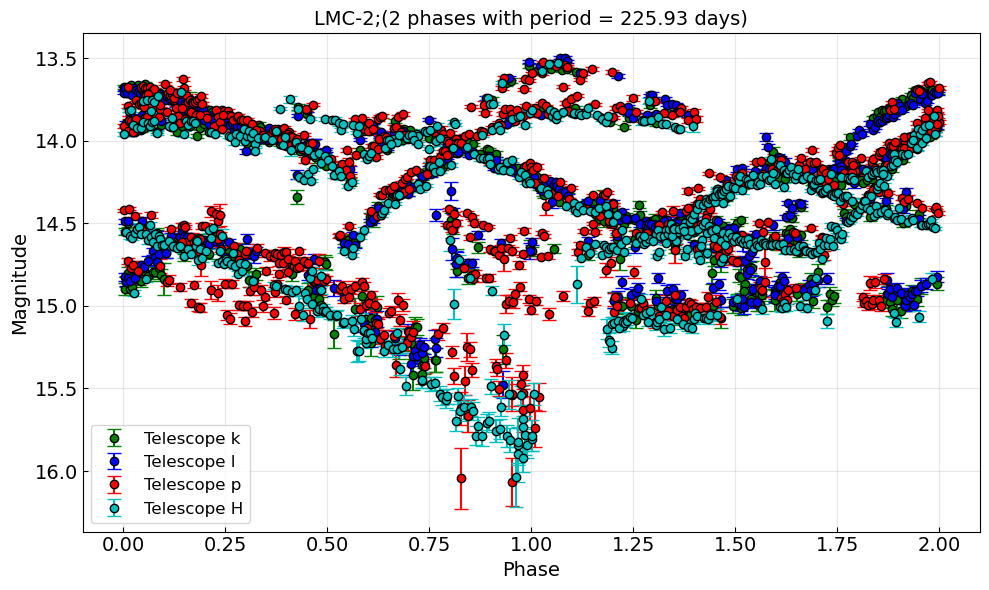

Average scatter (amplitude) per 10 point phase bin: 6.382 mJy


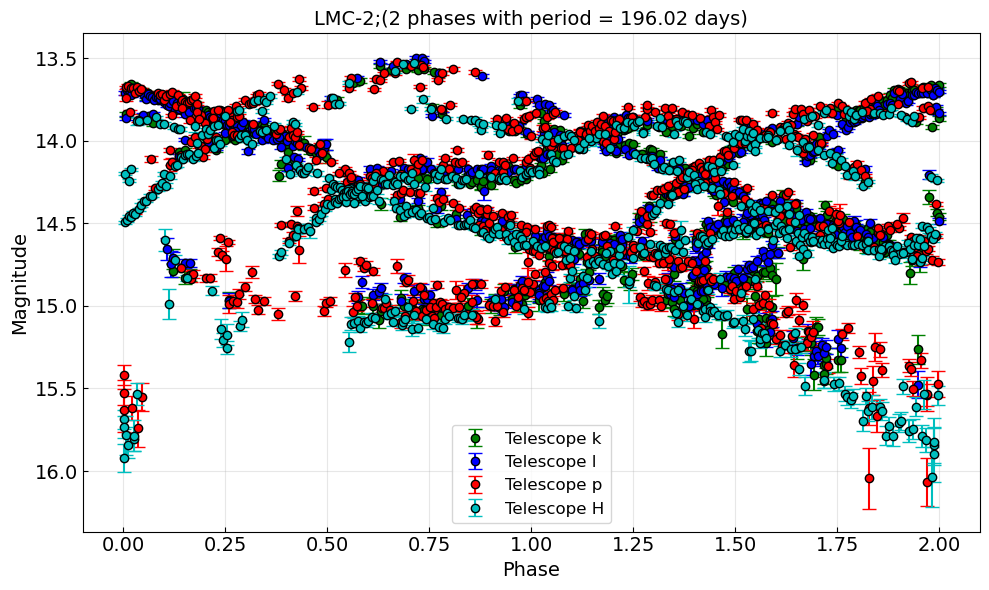

Average scatter (amplitude) per 10 point phase bin: 6.772 mJy


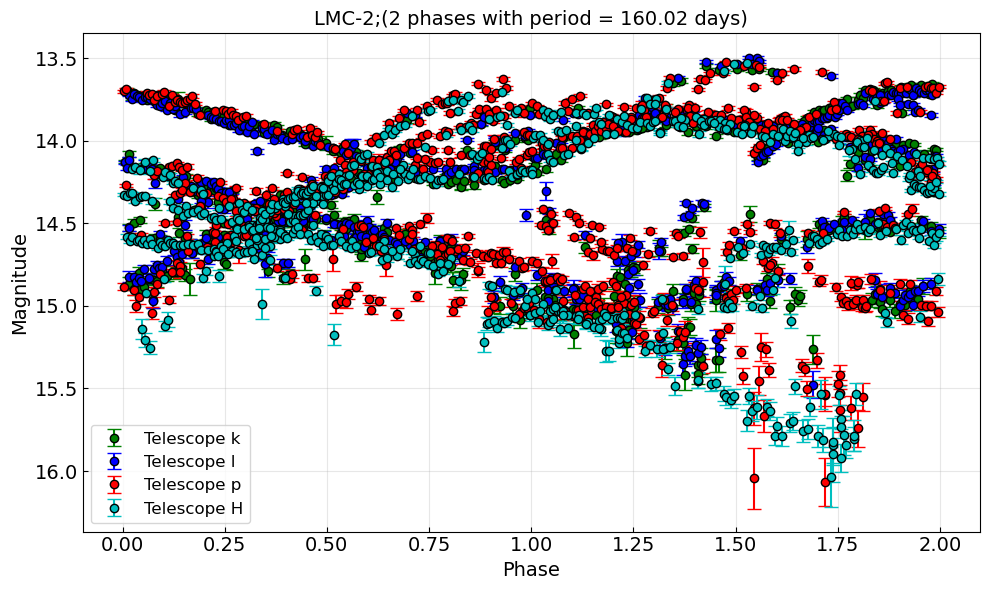

Average scatter (amplitude) per 10 point phase bin: 7.069 mJy


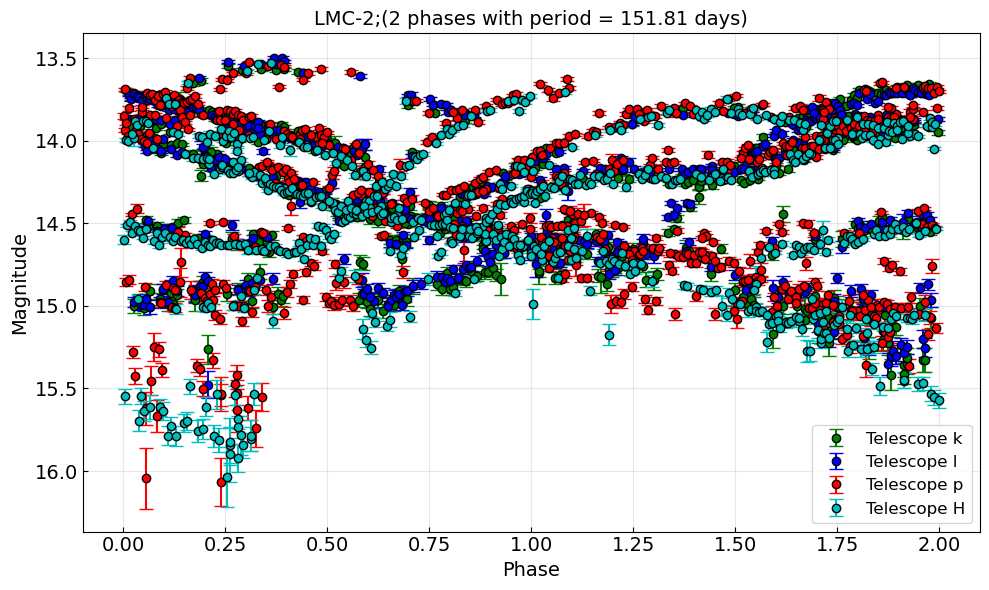

Average scatter (amplitude) per 10 point phase bin: 6.944 mJy


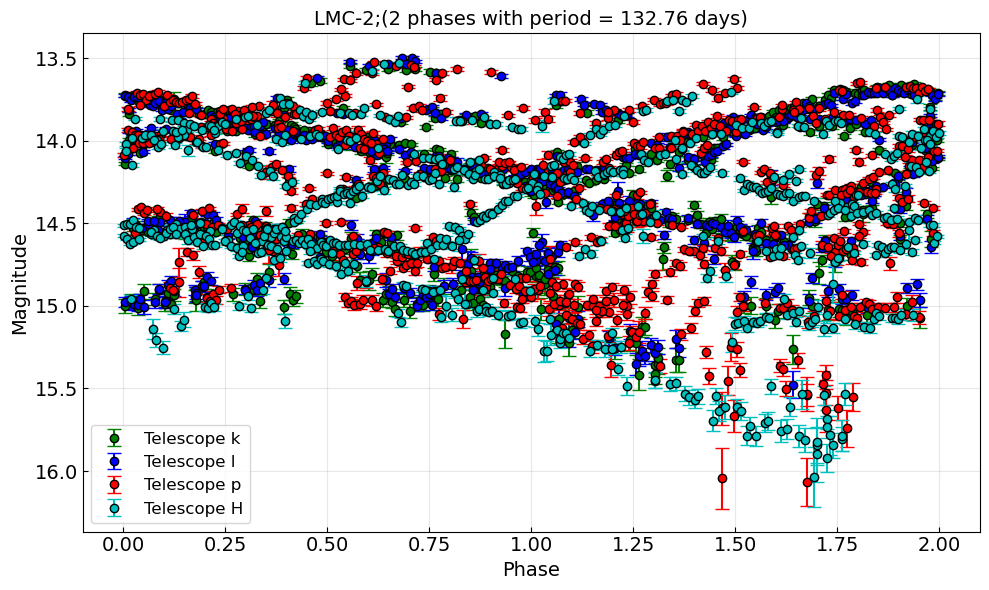

Average scatter (amplitude) per 10 point phase bin: 7.479 mJy


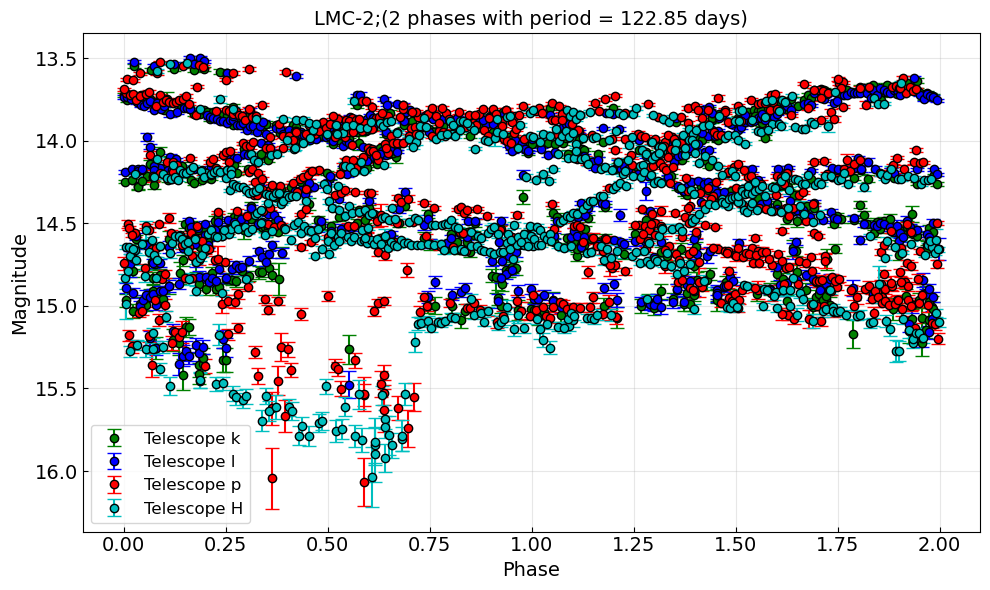

Average scatter (amplitude) per 10 point phase bin: 7.536 mJy


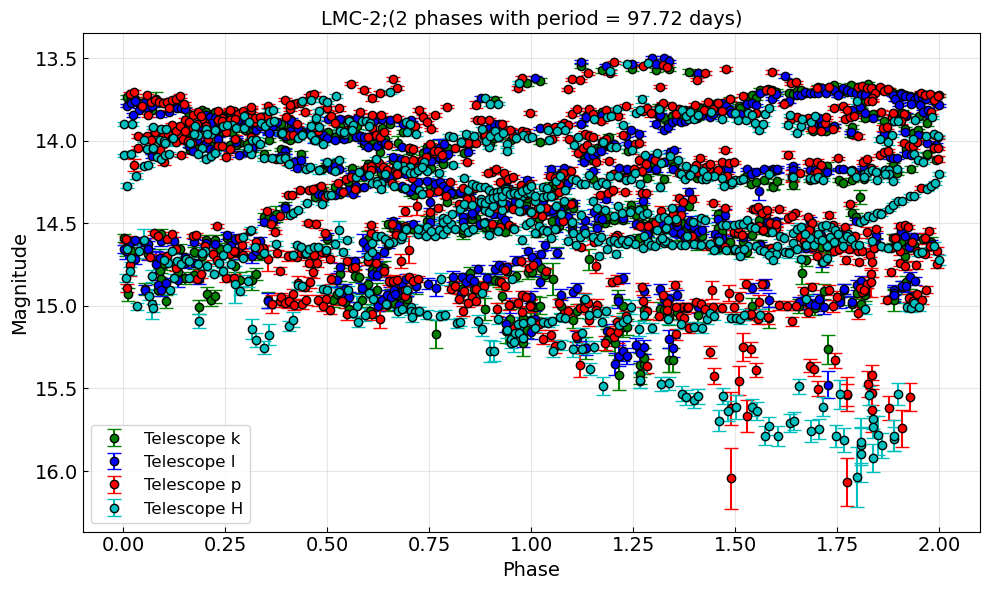

Average scatter (amplitude) per 10 point phase bin: 7.529 mJy


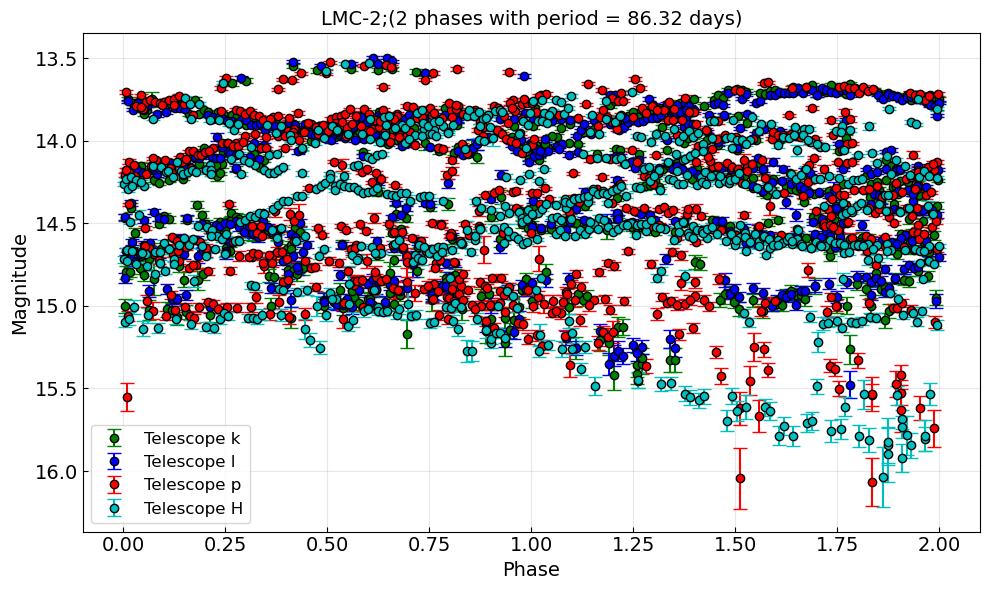

Average scatter (amplitude) per 10 point phase bin: 7.714 mJy


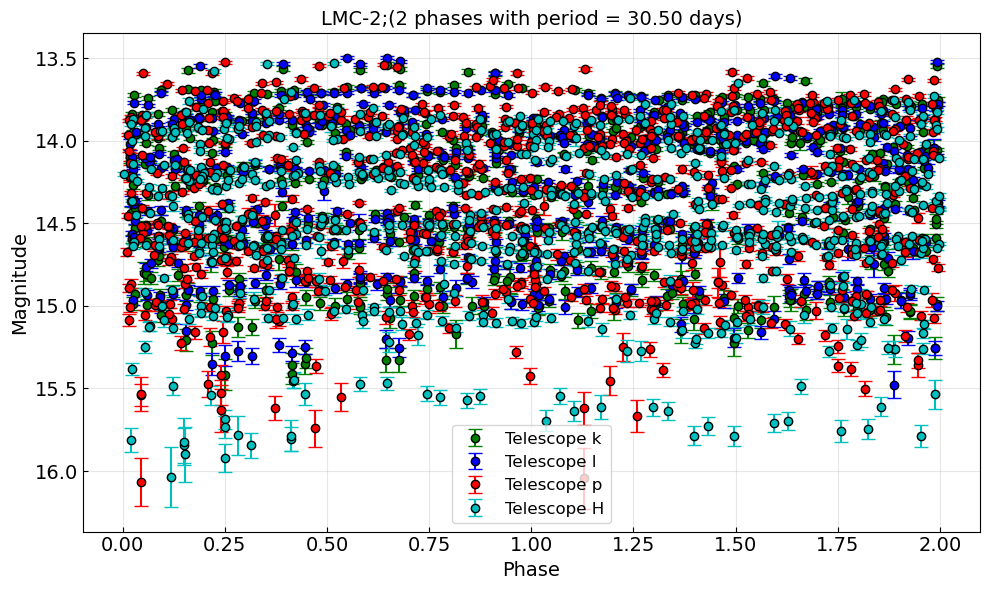

Average scatter (amplitude) per 10 point phase bin: 7.253 mJy


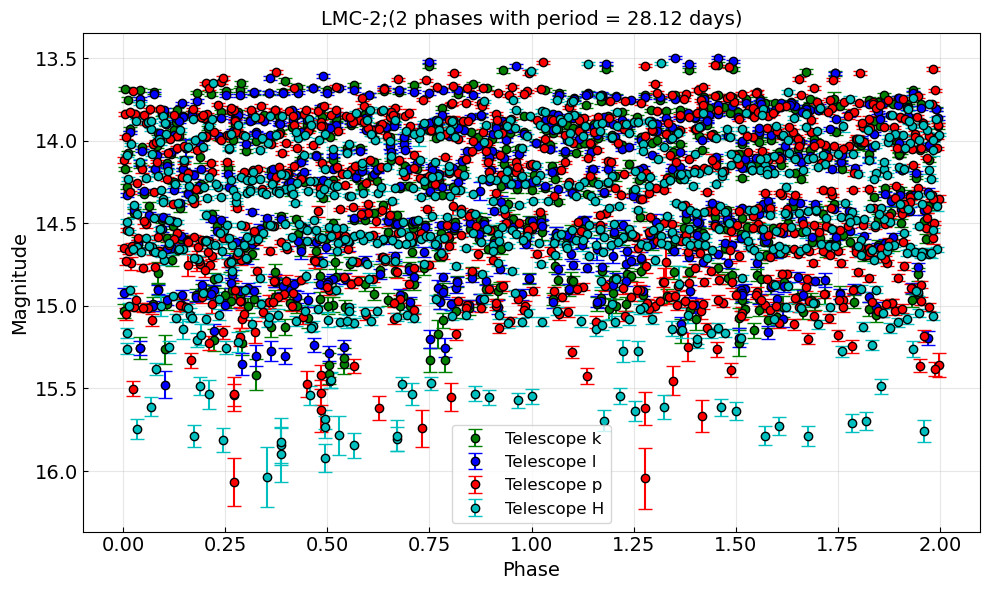

Average scatter (amplitude) per 10 point phase bin: 7.615 mJy


In [9]:
for freq in [0.00104964, 0.00165741, 0.00219764, 0.00253529, 0.00300799, 0.00341317, 0.00442611, 0.0051014,  0.0062494,  0.00658705, 0.00753246, 0.00814022, 0.01023363, 0.01158422, 0.03278842, 0.03555713]:
    best_period = 1.0 / freq
    plot_phase_fold(best_period, phase_bins=2, mag_space=True)
    # plot_phase_fold_binned(best_period, phase_bins=2, mag_space=True)